# High-Performance Black-Scholes-Merton Pricing Engine

In this notebook, we implement a closed-form analytical pricer for European options using the Black-Scholes-Merton (BSM) model. To ensure production-level performance suitable for High-Frequency environments or large portfolio valuations, the core mathematical functions are compiled to machine code using the Numba JIT compiler.

## 1. Mathematical framework

The most famous solutions of the equation: $$\frac{\partial f}{\partial t}+ rS\,\frac{\partial f}{\partial S}+ \frac{1}{2}\sigma^{2} S^{2}\,\frac{\partial^{2} f}{\partial S^{2}} = r f,$$
where we are assuming that the stock price follows
$dS=\mu S dt + \sigma S dz$, are the Black-Scholes-Merton formulas for the prices of European call and put options:
$$\begin{gather} c = S_0\,N(d_1) - K e^{-rT} N(d_2),\\ p = K e^{-rT} N(-d_2) - S_0\,N(-d_1),
\end{gather}$$
where:
$$\begin{gather} d_1 = \frac{\ln\!\left(\frac{S_0}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma \sqrt{T}},\\d_2 = \frac{\ln\!\left(\frac{S_0}{K}\right) + \left(r - \frac{\sigma^2}{2}\right)T}{\sigma \sqrt{T}}= d_1 - \sigma\sqrt{T},\\N(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} e^{-\frac{t^2}{2}} dt.
\end{gather}$$
$c$ and $p$ are the European call and put price, $S_0$ is the stock price at time zero, K is the strike price, $r$ is the continuously compounded risk-free rate $\sigma$ is the stock price volatility, and $T$ is the time 
to maturity of the option

We can implement these equations in order to obtain the prices in microseconds..

In [67]:
import math as mt # erf function is fast with numba
import time
from numba import njit
import matplotlib.pyplot as plt
import numpy as np

In [65]:
@njit
# We start by implementing the acumulated probability N(x) = 1/2 [1+erf(x/sqrt(2))]
def N(x):
    """Cumulative distribution function for standard normal."""
    return (1 + mt.erf(x / mt.sqrt(2.0))) / 2.0  
    
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """Calculates the BSM theoretical price and Vega (1%)."""
    if T <= 0.0:
        if option_type == 'call':
            return max(S - K, 0.0), 0.0
        else:
            return max(K - S, 0.0), 0.0
            
    d1 = (mt.log(S / K) + (r + sigma**2.0 / 2.0) * T) / (sigma * mt.sqrt(T)) # we define ore d1 and d2
    d2 = d1 - sigma * mt.sqrt(T)
    
    # Absolute Vega divided by 100 for a 1% implied volatility move (same for calls and puts)
    vega = S * mt.sqrt(T) * mt.exp(-d1**2.0 / 2.0) / mt.sqrt(2 * mt.pi) / 100.0 
    if option_type == 'call':
        return S * N(d1) - K * mt.exp(-r * T) * N(d2), vega
    else:
        return K * mt.exp(-r * T) * N(-d2) - S * N(-d1), vega

## 2. Performance Profiling

Benchmarking execution latency

In [24]:
# Warm-up the JIT compiler
_, _ = black_scholes(100.0, 105.0, 1.0, 0.03, 0.2, 'call')

# Profile the execution time
%timeit black_scholes(100.0, 105.0, 1.0, 0.03, 0.2, 'call')

1.09 µs ± 57.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


## 3. Model Validation (Put-Call Parity)

In [30]:
# Test parameters
S_test, K_test, T_test, r_test, sig_test = 100.0, 105.0, 1.0, 0.03, 0.2

C, _ = black_scholes(S_test, K_test, T_test, r_test, sig_test, 'call')
P, _ = black_scholes(S_test, K_test, T_test, r_test, sig_test, 'put')

# Put-Call Parity: C - P = S0 - K * exp(-rT)
lhs = C - P
rhs = S_test - K_test * mt.exp(-r_test * T_test)

assert abs(lhs - rhs) < 1e-6, "Model Inconsistency: Arbitrage-free condition (Put-Call Parity) violated."
print("Validation passed: Model is arbitrage-free. ✅")

Validation passed: Model is arbitrage-free. ✅


## 5. Risk Sensitivities: The Greeks

Greeks measure the sensitivity of the option price to different market parameters. They are essential for hedging and portfolio risk management. Below, we derive Delta, Gamma, Vega, Theta, and Rho using the BSM analytical framework.

In the BSM model, the Greeks can be calculated with the following expressions: 
- Delta ($\Delta$) - Sensibility to price
    - Call: $\Delta = N(d_1)$
    - Put: $\Delta = N(d_1) - 1$
- Gamma ($\Gamma$) - Curvature
    - $\Gamma = \frac{\phi(d_1)}{S \sigma \sqrt{T}}$
- Vega 1% ($\nu_{1}$) - Sensibility to volatility
    - $\nu = \frac{S_0 \sqrt{T} \phi(d_1)}{100}$
- Theta ($\Theta$) - Time decay
    - Call: $\Theta = -\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)$
    - Put: $\Theta = -\frac{S_0 \phi(d_1) \sigma}{2\sqrt{T}} + r K e^{-rT} N(-d_2)$
- Rho ($\rho$) - Sensibility to interest rates
    - Call: $\rho = K T e^{-rT} N(d_2)$
    - Put: $\rho = -K T e^{-rT} N(-d_2)$

In [61]:
@njit
def phi(x):
    """Probability Density Function (PDF) of standard normal."""
    return mt.exp(-0.5 * x**2) / mt.sqrt(2.0 * mt.pi)
 
def get_greeks(S, K, T, r, sigma, option_type='call'):
    """
    Calculates the analytical Greeks for European options using the BSM model.
    Optimized to minimize branching and redundant calculations.
    """
    # Standard BSM distance parameters
    d1 = (mt.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * mt.sqrt(T))
    d2 = d1 - sigma * mt.sqrt(T)
    
    # Common term for Theta and Gamma
    pdf_d1 = phi(d1)
    theta_term1 = -(S * pdf_d1 * sigma) / (2 * mt.sqrt(T))
    
    # Option-type dependent Greeks (Delta, Theta, Rho)
    if option_type == 'call':
        delta = N(d1)
        theta = theta_term1 - r * K * mt.exp(-r * T) * N(d2)
        rho = (K * T * mt.exp(-r * T) * N(d2)) / 100.0
    else:
        delta = N(d1) - 1.0
        theta = theta_term1 + r * K * mt.exp(-r * T) * N(-d2)
        rho = (-K * T * mt.exp(-r * T) * N(-d2)) / 100.0
        
    # Option-type independent Greeks (Gamma, Vega)
    # Gamma: Sensitivity of Delta to underlying price changes (Curvature)
    gamma = pdf_d1 / (S * sigma * mt.sqrt(T))
    
    # Vega: Sensitivity to a 1% change in implied volatility
    vega = (S * mt.sqrt(T) * pdf_d1) / 100.0

    # Daily Theta (Time decay per day)
    theta_day = theta / 365.0
        
    return {
        "Delta": delta,
        "Gamma": gamma,
        "Vega (1%)": vega,
        "Theta (Day)": theta_day,
        "Rho (1%)": rho
    }

In [62]:
# Warm-up the JIT compiler
_ = get_greeks(100.0, 105.0, 1.0, 0.03, 0.2, 'call')

# Profile the execution time
%timeit get_greeks(100.0, 105.0, 1.0, 0.03, 0.2, 'call')

1.57 µs ± 53.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [63]:
get_greeks(100.0, 105.0, 1.0, 0.03, 0.2, 'call')

{'Delta': 0.5024132586078932,
 'Gamma': 0.01994674906534299,
 'Vega (1%)': 0.39893498130685984,
 'Theta (Day)': -0.014473281229628564,
 'Rho (1%)': 0.43113261191527585}

We visualize the sensitivity profiles (Delta and Gamma) of the European Call option. This allows us to observe how the option's value responds to changes in the underlying asset price.

Computation Time for 200 points:  0.67 ms


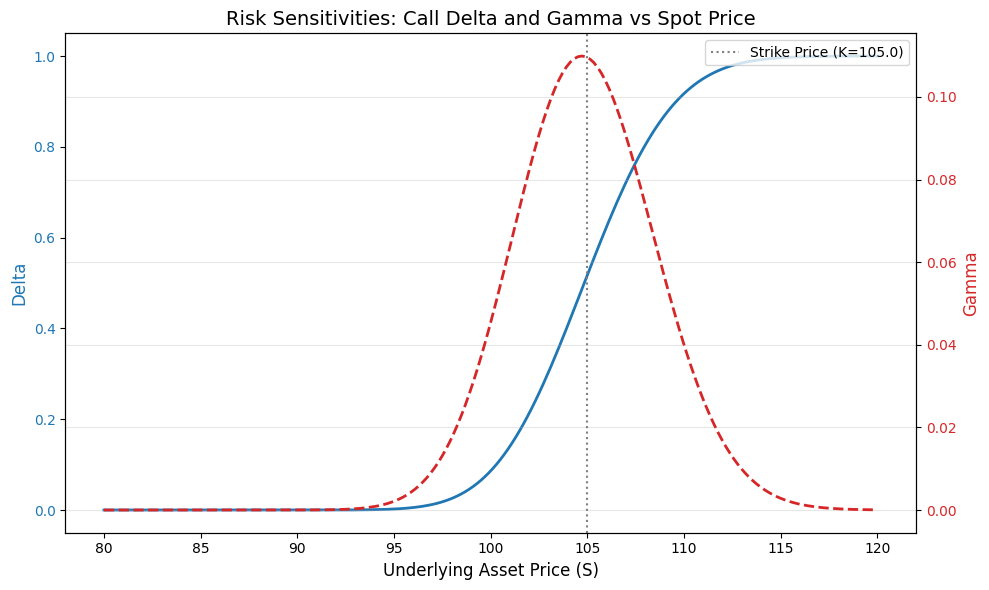

In [91]:
# Test parameters
K_test = 105.0
T_test = 0.03 # aprox 11 days 
r_test = 0.03
sigma_test = 0.2

t0 = time.perf_counter()
S_range = np.linspace(80, 120, 200)
deltas = []
gammas = []

# Calculate Greeks point by point using the analytical engine
for i in S_range:
    greeks = get_greeks(i, K_test, T_test, r_test, sigma_test, 'call')
    deltas.append(greeks["Delta"])
    gammas.append(greeks["Gamma"])
t1 = time.perf_counter()

print(f"Computation Time for 200 points: {(t1 - t0) * 1e3: .2f} ms")

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-axis (Delta)
color = 'tab:blue'
ax1.set_xlabel('Underlying Asset Price (S)', fontsize=12)
ax1.set_ylabel('Delta', color=color, fontsize=12)
ax1.plot(S_range, deltas, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Right Y-axis (Gamma)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Gamma', color=color, fontsize=12)
ax2.plot(S_range, gammas, color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Vertical line at Strike
plt.axvline(x=K_test, color='gray', linestyle=':', label=f'Strike Price (K={K_test})')
plt.title('Risk Sensitivities: Call Delta and Gamma vs Spot Price', fontsize=14)

plt.legend()
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

With a very short time to expiry (T = 0.03 years) the call Delta transitions from 0 to 1 over a very narrow spot range and Gamma becomes a sharp, high peak centered at the strike.

## 6. Conclusion: The Limits of Python and the Power of JIT

During performance profiling, an interesting architectural behavior was observed. For single scalar evaluations, the pure Python implementation is already highly optimized since the standard math module delegates operations directly to compiled C libraries. In fact, for an isolated option pricing, the Numba JIT dispatcher overhead (crossing the Python-C bridge) can actually outweigh the execution time of the math itself.

Therefore, Numba's true competitive advantage does not lie in single-path calculations, but rather in large-scale portfolio valuations or Monte Carlo simulations. In those scenarios, Numba eliminates the massive interpreter overhead of Python loops, unlocking C-level speeds for big data quantitative analysis.